In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.backends.cudnn as cudnn
import torchvision
import torchvision.transforms as transforms
import os
import argparse
from pathlib import Path
import re
import random
import math
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Reading the BF data

In [3]:
bf_path = '/content/drive/MyDrive/ALL_CLEAN_DEIDEN_NAME AND ECMO DATA(Sheet1) (1) (version 2).csv'
cols = ['ID', 'age_days', 'Diagnosis']
df = pd.read_csv(bf_path, usecols=cols)

for col in ['age_days']:
    s = pd.to_numeric(df[col], errors='coerce')
    mx = s.max(skipna=True)
    if pd.notna(mx) and mx != 0:
        df[col] = s / mx
    else:
        df[col] = s
print(df.head())

   ID  age_days            Diagnosis
0   1  0.018213       Cardiac Arrest
1   2  0.072852       Cardiac Arrest
2   3  0.793776               Sepsis
3   4  0.000287  Respiratory Failure
4   5  0.000287  Respiratory Failure


In [4]:
diag_clean = (
    df['Diagnosis']
      .astype('string')
      .str.strip()
      .str.replace(r'\s+', ' ', regex=True)
      .fillna('Unknown')
)

codes, uniques = pd.factorize(diag_clean, sort=True)
df['Diagnosis'] = codes.astype('int64')
diagnosis_mapping = {cat: int(i) for i, cat in enumerate(uniques)}
print("Diagnosis mapping (category -> code):", diagnosis_mapping)

# Peek
print(df.head())

Diagnosis mapping (category -> code): {'Cardiac Arrest': 0, 'Cardiogenic Shock': 1, 'Respiratory Failure': 2, 'Sepsis': 3, 'Septic shock': 4}
   ID  age_days  Diagnosis
0   1  0.018213          0
1   2  0.072852          0
2   3  0.793776          3
3   4  0.000287          2
4   5  0.000287          2


In [5]:
df.head()

,ID,age_days,Diagnosis
0,1,0.018213,0
1,2,0.072852,0
2,3,0.793776,3
3,4,0.000287,2
4,5,0.000287,2


### No normalization!

In [6]:
# === FULL SCRIPT (ORIGINAL / UNCALIBRATED) ===
from pathlib import Path
import re, random, math, os
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score, accuracy_score, roc_curve, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold, train_test_split

import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================
# Config
# =========================
SPLIT_DIR = r"/content/drive/MyDrive/CD/patient_data_clean_nozero_181920212223_1800"
save_dir  = "/content/drive/MyDrive/CD/2Bio_SHAP_v2/"
POS_PATIENTS = {1, 2, 16, 19, 21, 22, 25, 37, 39, 43, 44, 47, 50, 56, 58, 62, 65, 66, 73, 78}

# If your features are in a CSV, set FEATS_CSV = "path/to/features.csv" (must have column 'ID')
# If you already have a DataFrame named `df` in memory, leave this as None.
FEATS_CSV = None  # e.g., "/content/drive/MyDrive/CD/tabular_features.csv"

BATCH_SIZE = 3
EPOCHS     = 100
LR         = 1e-4
SEED       = 1
K_FOLDS    = 7

# (kept for reference; not used to fix height)
TARGET_H_DUMMY = 400

# =========================
# Noise config (train-time augmentation only, EEG input only)
# =========================
TRAIN_ADD_GAUSS_NOISE = True
TRAIN_NOISE_FRAC      = 0.0   # set >0 to actually add noise
TRAIN_NOISE_PROB      = 1.0
EPS_STD               = 1e-8

# Ensure base save dir exists
Path(save_dir).mkdir(parents=True, exist_ok=True)

# =========================
# Repro
# =========================
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
for g in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

# =========================
# Helpers
# =========================
PATIENT_NUM_RX = re.compile(r'^ID(\d+)')  # e.g., "ID76-2_..." -> 76

def patient_num_from_path(pathlike):
    stem = Path(pathlike).stem
    m = PATIENT_NUM_RX.match(stem)
    return int(m.group(1)) if m else None

def label_for_id(pid: int) -> int:
    return 1 if pid in POS_PATIENTS else 0

def label_for_file(p: Path) -> int:
    pid = patient_num_from_path(p)
    return label_for_id(pid) if pid is not None else 0

def youden_threshold(y_true, y_prob):
    """
    Compute Youden's J and the maximizing threshold on a labeled VALIDATION set.
    Returns (t_star, J, FPR_at_t_star, TPR_at_t_star).
    """
    if len(np.unique(y_true)) < 2:
        # Degenerate: one class present; return strict threshold
        return 1.0, 0.0, 0.0, 0.0
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    i = int(np.argmax(j))
    return float(thr[i]), float(j[i]), float(fpr[i]), float(tpr[i])

# =========================
# Load your existing features DataFrame: must contain 'ID' + feature columns
# =========================
if FEATS_CSV is not None:
    feats_df = pd.read_csv(FEATS_CSV)
else:
    try:
        feats_df = df.copy()  # expects `df` already in memory
    except NameError as e:
        raise RuntimeError("No features found. Set FEATS_CSV to a CSV with column 'ID', "
                           "or pre-load a DataFrame named `df`.") from e

if "ID" not in feats_df.columns:
    raise RuntimeError("Your features DataFrame must contain column 'ID'.")

FEAT_COLS = [c for c in feats_df.columns if c != "ID"]
if len(FEAT_COLS) == 0:
    raise RuntimeError("No feature columns found (columns other than 'ID').")

FEAT_DIM = len(FEAT_COLS)
print("FEAT_DIM =", FEAT_DIM)

# Clean and index by ID; drop rows with missing any of the features
feats_df["ID"] = pd.to_numeric(feats_df["ID"], errors="coerce").astype("Int64")
feats_df = feats_df.dropna(subset=["ID"] + FEAT_COLS).copy()
feats_df["ID"] = feats_df["ID"].astype(int)

ID_TO_FEAT = {
    int(row["ID"]): row[FEAT_COLS].astype("float32").to_numpy()
    for _, row in feats_df.iterrows()
}

# =========================
# Enumerate EEG files and keep only IDs present in features
# =========================
split_dir = Path(SPLIT_DIR)
all_csvs = sorted(split_dir.glob("*.csv"))
if not all_csvs:
    raise FileNotFoundError(f"No CSV found in {SPLIT_DIR}")

id_to_files = {}
for f in all_csvs:
    pid = patient_num_from_path(f)
    if pid is None:
        continue
    if pid in ID_TO_FEAT:  # keep only IDs with features
        id_to_files.setdefault(pid, []).append(f)

valid_ids = sorted(id_to_files.keys())
if not valid_ids:
    raise RuntimeError("No overlapping patient IDs between files and features table.")

y_ids = np.array([label_for_id(pid) for pid in valid_ids], dtype=int)
print("Total valid IDs:", len(valid_ids), "| Pos IDs:", y_ids.sum(), "| Neg IDs:", (1 - y_ids).sum())

# =========================
# Utilities for loading & shaping EEG (de-dup consecutive rows)
# =========================
def _drop_time_cols(df_in: pd.DataFrame) -> pd.DataFrame:
    time_like = [c for c in df_in.columns if isinstance(c, str) and c.strip().lower() == "time"]
    return df_in.drop(columns=time_like, errors="ignore")

def _to_numeric_df(df_in: pd.DataFrame) -> pd.DataFrame:
    df_in = _drop_time_cols(df_in)
    return df_in.apply(pd.to_numeric, errors="coerce").fillna(0.0)

def _pad_crop_2d(x: np.ndarray, H: int, W: int) -> np.ndarray:
    h, w = x.shape
    if h < H:
        pad = np.zeros((H, w), dtype=x.dtype)
        pad[:h, :] = x
        x = pad; h = H
    elif h > H:
        x = x[:H, :]; h = H
    if w < W:
        pad = np.zeros((h, W), dtype=x.dtype)
        pad[:, :w] = x
        x = pad
    elif w > W:
        x = x[:, :W]
    return x

def _dedupe_consecutive_rows(mat: np.ndarray) -> np.ndarray:
    if mat.size == 0:
        return mat
    if mat.ndim == 1:
        mat = mat[:, None]
    if mat.shape[0] == 1:
        return mat
    diffs = np.any(mat[1:] != mat[:-1], axis=1)
    keep = np.concatenate(([True], diffs))
    return mat[keep]

def _infer_target_width(example_csv: Path) -> int:
    df0 = pd.read_csv(example_csv)
    df2 = _to_numeric_df(df0)
    return df2.shape[1]

# Width is fixed by columns in first valid sample
TARGET_W = _infer_target_width(id_to_files[valid_ids[0]][0])
print(f"TARGET_W={TARGET_W} (non-Time columns)")

# Height: max de-dup length across ALL eligible files (fixed for all folds)
def _dedup_len_from_csv(p: Path) -> int:
    dfx = pd.read_csv(p)
    mat = _to_numeric_df(dfx).to_numpy(dtype=np.float32)
    mat_d = _dedupe_consecutive_rows(mat)
    return int(mat_d.shape[0])

ALL_ELIGIBLE_FILES = [f for pid in valid_ids for f in id_to_files[pid]]
TARGET_H_DEDUP = max(_dedup_len_from_csv(f) for f in ALL_ELIGIBLE_FILES)
if TARGET_H_DEDUP <= 0:
    raise RuntimeError("After de-dup, zero-length found in data.")
print(f"Fixed input height after de-dup (all IDs): H={TARGET_H_DEDUP}")

def load_csv_as_image_dedup(csv_path: Path) -> np.ndarray:
    df0 = pd.read_csv(csv_path)
    df2 = _to_numeric_df(df0)
    mat = df2.to_numpy(dtype=np.float32)
    if mat.ndim != 2:
        mat = mat.reshape(mat.shape[0], -1) if mat.ndim > 2 else mat
    mat = _dedupe_consecutive_rows(mat)
    if mat.shape[0] == 0:
        mat = np.zeros((1, TARGET_W), dtype=np.float32)
    mat = _pad_crop_2d(mat, TARGET_H_DEDUP, TARGET_W)
    img = np.expand_dims(mat, axis=-1).astype(np.float32)  # (H, W, 1)
    if img.shape != (TARGET_H_DEDUP, TARGET_W, 1):
        raise ValueError(f"loader produced {img.shape}, expected {(TARGET_H_DEDUP, TARGET_W, 1)}")
    return img

CACHE_DEDUP = {}
def load_csv_as_image_cached(csv_path: Path) -> np.ndarray:
    key = str(csv_path)
    if key in CACHE_DEDUP:
        return CACHE_DEDUP[key]
    img = load_csv_as_image_dedup(csv_path)
    CACHE_DEDUP[key] = img
    return img

# =========================
# Keras Sequence — returns ({"eeg_input": X_img, "tab_input": X_tab}, y)
# =========================
class ImageSequence(keras.utils.Sequence):
    def __init__(self, files, batch_size=BATCH_SIZE, shuffle=True,
                 add_noise=False, noise_frac=TRAIN_NOISE_FRAC, noise_prob=TRAIN_NOISE_PROB):
        super().__init__()
        self.files = list(files)
        self.batch_size = int(batch_size)
        self.shuffle = shuffle
        self.add_noise = add_noise
        self.noise_frac = float(noise_frac)
        self.noise_prob = float(noise_prob)
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.files) / self.batch_size)

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.files))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, idx):
        idxs = self.indexes[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_files = [self.files[i] for i in idxs]
        B = len(batch_files)

        X_img = np.empty((B, TARGET_H_DEDUP, TARGET_W, 1), dtype=np.float32)
        X_tab = np.empty((B, FEAT_DIM), dtype=np.float32)
        y     = np.empty((B,), dtype=np.int32)

        for i, f in enumerate(batch_files):
            xi = load_csv_as_image_cached(f)
            if xi.ndim == 2:
                xi = xi[..., None]
            if xi.shape != (TARGET_H_DEDUP, TARGET_W, 1):
                raise ValueError(f"Sample shape {xi.shape} for {f}")
            X_img[i] = xi
            pid = patient_num_from_path(f)
            X_tab[i] = ID_TO_FEAT[pid]
            y[i] = label_for_file(f)

        # Gaussian noise on EEG only (train)
        if self.add_noise and self.noise_frac > 0.0 and self.noise_prob > 0.0:
            samp_std = X_img.reshape(B, -1).std(axis=1).astype(np.float32)
            samp_std = np.maximum(samp_std, EPS_STD).reshape(B, 1, 1, 1)
            noise = np.random.normal(0.0, 1.0, size=X_img.shape).astype(np.float32)
            noise *= (self.noise_frac * samp_std)
            if self.noise_prob < 1.0:
                mask = (np.random.rand(B, 1, 1, 1) < self.noise_prob).astype(np.float32)
                noise *= mask
            X_img = X_img + noise

        return {"eeg_input": X_img, "tab_input": X_tab}, y

# =========================
# Two-input Model: CNN (EEG) + MLP (tabular features)
# =========================
def build_model(h=TARGET_H_DEDUP, w=TARGET_W, c=1, lr=LR,
                growth_rate=8, block_layers=(2,2,2,2),
                compression=0.2, dropout=0.2, tab_dim=FEAT_DIM):

    eeg_in = keras.Input(shape=(h, w, c), name="eeg_input")

    def bn_relu_conv(x, filters, ksize, stride=1):
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, ksize, strides=stride, padding="same", use_bias=False)(x)
        return x

    def dense_layer(x):
        y = bn_relu_conv(x, 4 * growth_rate, 1)
        y = bn_relu_conv(y, growth_rate, 3)
        return layers.Concatenate()([x, y])

    def dense_block(x, L):
        for _ in range(L):
            x = dense_layer(x)
        return x

    def transition_layer(x):
        filters = max(8, int(int(x.shape[-1]) * compression))
        x = bn_relu_conv(x, filters, 1)
        return layers.AveragePooling2D(pool_size=(2, 2), strides=2, padding="same")(x)

    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(eeg_in)
    x = layers.ReLU()(x)
    for i, L in enumerate(block_layers):
        x = dense_block(x, L)
        if i != len(block_layers) - 1:
            x = transition_layer(x)
    x = layers.GlobalAveragePooling2D()(x)  # (B, F_eeg)

    tab_in = keras.Input(shape=(tab_dim,), name="tab_input")
    t = layers.Dense(8, activation="relu")(tab_in)
    t = layers.Dense(8, activation="relu")(t)

    z = layers.Concatenate()([x, t])
    z = layers.Dropout(dropout)(z)
    z = layers.Dense(8, activation="relu")(z)
    z = layers.Dropout(dropout)(z)
    out = layers.Dense(1, activation="sigmoid")(z)

    model = keras.Model(inputs=[eeg_in, tab_in], outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.BinaryAccuracy(name="acc"),
                 keras.metrics.AUC(name="auc")],
    )
    return model

# =========================
# Helper: ROC plot for TEST set
# =========================
def plot_roc(y_true, probs, title, out_png):
    try:
        if len(np.unique(y_true)) < 2:
            print(f"(Warning) ROC plot skipped for {title}: only one class present.")
            return
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc_val = roc_auc_score(y_true, probs)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc_val:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(title)
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(out_png, dpi=200)
        plt.close()
        print(f"Saved ROC to {out_png}")
    except Exception as e:
        print(f"(Warning) ROC plot failed for {title}: {e}")

# =========================
# Build folds by ID (outer = train/test; inner = val)
# =========================
valid_ids_arr = np.array(valid_ids)
labels_arr    = np.array([label_for_id(pid) for pid in valid_ids_arr], dtype=int)

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)

fold_test_aucs = []
fold_test_accs_at_youden = []
fold_test_accs_at_05 = []

youden_thresholds = []
youden_Js         = []

print("\n=== 7-Fold CV (by patient ID; TEST metrics saved) ===")
for fold_idx, (train_idx, test_idx) in enumerate(skf.split(valid_ids_arr, labels_arr), start=1):
    # --- per-fold directory (ckpt_path) ---
    ckpt_path = Path(save_dir) / f"fold_{fold_idx:02d}"
    ckpt_path.mkdir(parents=True, exist_ok=True)

    # Outer split: train vs test (by ID)
    ids_train_full = [int(valid_ids_arr[i]) for i in train_idx]
    ids_test       = [int(valid_ids_arr[i]) for i in test_idx]

    # Inner split: carve VAL from training IDs (for checkpoint selection)
    train_labels_full = np.array([label_for_id(pid) for pid in ids_train_full], dtype=int)
    try:
        ids_tr, ids_val = train_test_split(
            ids_train_full, test_size=0.10, random_state=SEED, stratify=train_labels_full
        )
    except ValueError:
        ids_tr, ids_val = train_test_split(
            ids_train_full, test_size=0.10, random_state=SEED, shuffle=True
        )
        print(f"(Fold {fold_idx}) Warning: stratified VAL split failed; using unstratified split.")

    # Files for each split
    train_files = [f for pid in ids_tr   for f in id_to_files[pid]]
    val_files   = [f for pid in ids_val  for f in id_to_files[pid]]
    test_files  = [f for pid in ids_test for f in id_to_files[pid]]

    # --- save the splits under ckpt_path ---
    (ckpt_path / "train_files.txt").write_text("\n".join(map(str, train_files)))
    (ckpt_path / "val_files.txt").write_text("\n".join(map(str, val_files)))
    (ckpt_path / "test_files.txt").write_text("\n".join(map(str, test_files)))
    pd.Series(ids_tr,  name="train_ids").to_csv(ckpt_path / "train_ids.csv", index=False)
    pd.Series(ids_val, name="val_ids").to_csv(  ckpt_path / "val_ids.csv",   index=False)
    pd.Series(ids_test,name="test_ids").to_csv( ckpt_path / "test_ids.csv",  index=False)
    print('save successful!')
    print(f"\n--- Fold {fold_idx}/{K_FOLDS} ---")
    print(f" train files: {len(train_files)} | val files: {len(val_files)} | test files: {len(test_files)}")

    # Generators
    train_gen = ImageSequence(train_files, batch_size=BATCH_SIZE, shuffle=True,
                              add_noise=TRAIN_ADD_GAUSS_NOISE)
    val_gen   = ImageSequence(val_files,   batch_size=BATCH_SIZE, shuffle=False,
                              add_noise=False)
    test_gen  = ImageSequence(test_files,  batch_size=BATCH_SIZE, shuffle=False,
                              add_noise=False)

    # Train with VAL for model selection
    model = build_model()
    weights_file = ckpt_path / f"best_fold_{fold_idx:02d}.h5"
    ckpt = keras.callbacks.ModelCheckpoint(
        str(weights_file), monitor="val_loss", mode="min", save_best_only=True, verbose=0
    )
    hist = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,
                     callbacks=[ckpt], verbose=0)

    # --- save training history CSV ---
    pd.DataFrame(hist.history).to_csv(ckpt_path / "history.csv", index=False)

    # --- plot training curves (loss & val_loss) ---
    try:
        plt.figure()
        plt.plot(hist.history.get("loss", []), label="loss")
        plt.plot(hist.history.get("val_loss", []), label="val_loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss — Fold {fold_idx:02d}")
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.savefig(ckpt_path / f"history_loss_fold_{fold_idx:02d}.png", dpi=200)
        plt.close()
    except Exception as e:
        print(f"(Fold {fold_idx:02d}) Warning: failed to plot loss curves: {e}")

    # --- plot training curves (AUC & ACC) ---
    try:
        plt.figure()
        if "auc" in hist.history: plt.plot(hist.history["auc"], label="auc")
        if "val_auc" in hist.history: plt.plot(hist.history["val_auc"], label="val_auc")
        if "acc" in hist.history: plt.plot(hist.history["acc"], label="acc")
        if "val_acc" in hist.history: plt.plot(hist.history["val_acc"], label="val_acc")
        plt.xlabel("Epoch"); plt.ylabel("Metric"); plt.title(f"Metrics — Fold {fold_idx:02d}")
        plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
        plt.savefig(ckpt_path / f"history_auc_acc_fold_{fold_idx:02d}.png", dpi=200)
        plt.close()
    except Exception as e:
        print(f"(Fold {fold_idx:02d}) Warning: failed to plot metric curves: {e}")

    # === Load best epoch (by val_loss) ===
    best_model = keras.models.load_model(str(weights_file))

    # === VALIDATION: pick Youden-J threshold using the best model (RAW) ===
    val_probs = best_model.predict(val_gen, verbose=0).ravel().astype(float)
    val_y     = np.array([label_for_file(f) for f in val_gen.files], dtype=int)

    t_star, J_val, fpr_v, tpr_v = youden_threshold(val_y, val_probs)
    youden_thresholds.append(t_star)
    youden_Js.append(J_val)

    # Save val ROC/Youden summary for traceability
    val_auc = roc_auc_score(val_y, val_probs) if len(np.unique(val_y)) == 2 else float("nan")
    pd.DataFrame({
        "fold":        [fold_idx],
        "val_auc":     [val_auc],
        "youden_t":    [t_star],
        "youden_J":    [J_val],
        "youden_FPR":  [fpr_v],
        "youden_TPR":  [tpr_v]
    }).to_csv(ckpt_path / "youden_val.csv", index=False)

    # --- TEST: evaluate at 0.5 (reference) and at frozen Youden t* (from VAL) ---
    test_probs = best_model.predict(test_gen, verbose=0).ravel().astype(float)
    test_y     = np.array([label_for_file(f) for f in test_gen.files], dtype=int)

    # Save raw predictions
    pd.DataFrame({
        "file":   [str(f) for f in test_gen.files],
        "y_true": test_y,
        "prob":   test_probs
    }).to_csv(ckpt_path / "test_predictions.csv", index=False)

    # Threshold-free
    try:
        test_auc = roc_auc_score(test_y, test_probs)
    except ValueError:
        test_auc = float('nan')

    # Thresholded metrics
    test_acc_05 = accuracy_score(test_y, (test_probs >= 0.5).astype(int))
    test_acc_Y  = accuracy_score(test_y, (test_probs >= t_star).astype(int))

    fold_test_aucs.append(float(test_auc))
    fold_test_accs_at_youden.append(float(test_acc_Y))
    fold_test_accs_at_05.append(float(test_acc_05))

    print(f" Fold {fold_idx:2d} | TEST AUC={test_auc:.4f} | "
          f"ACC@0.5={test_acc_05:.4f} | ACC@Youden={test_acc_Y:.4f} (t*={t_star:.3f}) | n={len(test_y)}")

    # Save ROC plot
    plot_roc(test_y, test_probs,
             title=f"ROC — TEST Fold {fold_idx:02d} (n={len(test_y)})",
             out_png=ckpt_path / f"roc_test_fold_{fold_idx:02d}.png")

    # Save per-fold metrics (include thresholds)
    pd.DataFrame({
        "fold":       [fold_idx],
        "n_test":     [len(test_y)],
        "test_auc":   [test_auc],
        "acc_at_0p5": [test_acc_05],
        "acc_at_J":   [test_acc_Y],
        "youden_t":   [t_star],
        "youden_J":   [J_val]
    }).to_csv(ckpt_path / f"metrics_fold_{fold_idx:02d}.csv", index=False)

# =========================
# Summary & save (TEST only)
# =========================
metrics_df = pd.DataFrame({
    "fold": np.arange(1, K_FOLDS+1),
    "test_auc": fold_test_aucs,
    "test_acc_at_youden": fold_test_accs_at_youden,
    "test_acc_at_0p5": fold_test_accs_at_05,
    "youden_t": youden_thresholds,
    "youden_J": youden_Js
})
summary_csv = Path(save_dir) / "cv_fold_test_metrics.csv"
metrics_df.to_csv(summary_csv, index=False)

valid_test_aucs = [a for a in fold_test_aucs if not np.isnan(a)]
if valid_test_aucs:
    print(f"\nMean TEST AUC: {np.mean(valid_test_aucs):.4f} ± {np.std(valid_test_aucs):.4f}")
else:
    print("\nMean TEST AUC: N/A (all NaN)")

print(f"Mean TEST ACC @ Youden: {np.mean(fold_test_accs_at_youden):.4f} ± {np.std(fold_test_accs_at_youden):.4f}")
print(f"Mean TEST ACC @ 0.5:    {np.mean(fold_test_accs_at_05):.4f} ± {np.std(fold_test_accs_at_05):.4f}")

print(f"\nSaved per-fold Youden thresholds to {Path(save_dir) / 'cv_youden_thresholds.csv'}")
print(f"Saved TEST-only metrics to {summary_csv} and per-fold artifacts under {save_dir}")

# ============ Extra: print Youden-J per fold (uncalibrated; from files just written) ============
try:
    rows = []
    for f in sorted(Path(save_dir).glob("fold_*")):
        yv = pd.read_csv(f / "youden_val.csv")
        rows.append({"fold": f.name, "youden_t": float(yv["youden_t"].iloc[0]), "youden_J": float(yv["youden_J"].iloc[0])})
    jtab = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)
    with pd.option_context('display.float_format', '{:.6f}'.format):
        print("\nYouden (validation, raw) per fold:")
        print(jtab.to_string(index=False))
    print(f"\nSaved overall summary to: {summary_csv}")
except Exception as e:
    print(f"(Note) Could not print Youden table: {e}")


FEAT_DIM = 2
Total valid IDs: 43 | Pos IDs: 14 | Neg IDs: 29
TARGET_W=6 (non-Time columns)
Fixed input height after de-dup (all IDs): H=360

=== 7-Fold CV (by patient ID; TEST metrics saved) ===
save successful!

--- Fold 1/7 ---
 train files: 776 | val files: 121 | test files: 293


 Fold  1 | TEST AUC=0.5261 | ACC@0.5=0.7031 | ACC@Youden=0.6246 (t*=0.237) | n=293
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_v2/fold_01/roc_test_fold_01.png
save successful!

--- Fold 2/7 ---
 train files: 987 | val files: 79 | test files: 124


 Fold  2 | TEST AUC=0.9232 | ACC@0.5=0.6774 | ACC@Youden=0.6452 (t*=0.402) | n=124
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_v2/fold_02/roc_test_fold_02.png
save successful!

--- Fold 3/7 ---
 train files: 1021 | val files: 42 | test files: 127


 Fold  3 | TEST AUC=0.9439 | ACC@0.5=0.3622 | ACC@Youden=0.8504 (t*=0.167) | n=127
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_v2/fold_03/roc_test_fold_03.png
save successful!

--- Fold 4/7 ---
 train files: 953 | val files: 168 | test files: 69


 Fold  4 | TEST AUC=0.9795 | ACC@0.5=0.9855 | ACC@Youden=0.9855 (t*=0.370) | n=69
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_v2/fold_04/roc_test_fold_04.png
save successful!

--- Fold 5/7 ---
 train files: 922 | val files: 158 | test files: 110


 Fold  5 | TEST AUC=0.9617 | ACC@0.5=0.3636 | ACC@Youden=0.3636 (t*=0.257) | n=110
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_v2/fold_05/roc_test_fold_05.png
save successful!

--- Fold 6/7 ---
 train files: 826 | val files: 121 | test files: 243


 Fold  6 | TEST AUC=0.8808 | ACC@0.5=0.8436 | ACC@Youden=0.9136 (t*=0.312) | n=243
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_v2/fold_06/roc_test_fold_06.png
save successful!

--- Fold 7/7 ---
 train files: 850 | val files: 116 | test files: 224


 Fold  7 | TEST AUC=1.0000 | ACC@0.5=0.8438 | ACC@Youden=0.7277 (t*=0.418) | n=224
Saved ROC to /content/drive/MyDrive/CD/2Bio_SHAP_v2/fold_07/roc_test_fold_07.png

Mean TEST AUC: 0.8879 ± 0.1520
Mean TEST ACC @ Youden: 0.7301 ± 0.1949
Mean TEST ACC @ 0.5:    0.6827 ± 0.2231

Saved per-fold Youden thresholds to /content/drive/MyDrive/CD/2Bio_SHAP_v2/cv_youden_thresholds.csv
Saved TEST-only metrics to /content/drive/MyDrive/CD/2Bio_SHAP_v2/cv_fold_test_metrics.csv and per-fold artifacts under /content/drive/MyDrive/CD/2Bio_SHAP_v2/

Youden (validation, raw) per fold:
   fold  youden_t  youden_J
fold_01  0.237211  0.933333
fold_02  0.401690  0.947368
fold_03  0.166681  0.878049
fold_04  0.369534  0.640081
fold_05  0.256723  0.503185
fold_06  0.311716  0.850000
fold_07  0.418245  0.713043

Saved overall summary to: /content/drive/MyDrive/CD/2Bio_SHAP_v2/cv_fold_test_metrics.csv


In [19]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, f1_score, matthews_corrcoef

PREFER_CALIBRATED = True  # prefer calibrated predictions if present
save_dir = Path('/content/drive/MyDrive/CD/2Bio_SHAP_v2/')

# ---------- helpers ----------
def _numeric_fold_sort_key(p: Path):
    try:
        return int(p.name.split("_")[-1])
    except Exception:
        return p.name

def safe_confusion_counts(y_true, y_hat):
    cm = confusion_matrix(y_true, y_hat, labels=[0,1])
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    return tn, fp, fn, tp

def metrics_at_threshold(y_true, y_prob, t):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_hat  = (y_prob >= t).astype(int)

    tn, fp, fn, tp = safe_confusion_counts(y_true, y_hat)
    n = tn + fp + fn + tp
    eps = 1e-12

    acc  = (tp + tn) / (n + eps)
    tpr  = tp / (tp + fn + eps)
    tnr  = tn / (tn + fp + eps)
    ppv  = tp / (tp + fp + eps)
    npv  = tn / (tn + fn + eps)
    bal  = 0.5 * (tpr + tnr)

    f1   = f1_score(y_true, y_hat, zero_division=0)
    try:
        mcc = matthews_corrcoef(y_true, y_hat)
        if not np.isfinite(mcc): mcc = 0.0
    except Exception:
        mcc = 0.0

    return {
        "ACC": acc, "BalancedAcc": bal, "MCC": mcc, "F1": f1,
        "TPR": tpr, "TNR": tnr, "PPV": ppv, "NPV": npv,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn, "n": n
    }

# Try to find a label and probability/score column
_LABEL_CANDIDATES = ["y_true", "label", "y", "target", "gt", "truth"]
_SCORE_CANDIDATES = ["prob", "proba", "score", "pred", "prediction", "p",
                     "probability", "prob_raw", "prob_cal", "calibrated_prob",
                     "logit", "logits"]

def pick_columns(df: pd.DataFrame):
    cols_lower = {c.lower(): c for c in df.columns}
    # label
    y_col = None
    for k in _LABEL_CANDIDATES:
        if k in cols_lower:
            y_col = cols_lower[k]; break
    # score
    s_col = None
    for k in _SCORE_CANDIDATES:
        if k in cols_lower:
            s_col = cols_lower[k]; break
    # fallback: try to infer a numeric score column (excluding obvious non-score columns)
    if s_col is None:
        exclude = set([y_col, cols_lower.get("file"), cols_lower.get("path")])
        numeric_cols = [c for c in df.columns if c not in exclude and np.issubdtype(df[c].dtype, np.number)]
        if numeric_cols:
            s_col = numeric_cols[-1]  # last numeric column as a last resort
    return y_col, s_col

# ---------- main ----------
fold_dirs = sorted([p for p in save_dir.glob("fold_*") if p.is_dir()],
                   key=_numeric_fold_sort_key)

rows = []
if not fold_dirs:
    raise RuntimeError(f"No fold_* directories found under {save_dir}")

for fd in fold_dirs:
    yv_path = fd / "youden_val.csv"
    tp_cal  = fd / "test_predictions_calibrated.csv"
    tp_raw  = fd / "test_predictions.csv"

    if not yv_path.exists():
        print(f"(skip) Missing youden_val.csv in {fd.name}")
        continue

    # choose file
    tp_path = tp_cal if (PREFER_CALIBRATED and tp_cal.exists()) else (tp_raw if tp_raw.exists() else None)
    if tp_path is None:
        print(f"(skip) Missing test predictions in {fd.name}")
        continue

    # read
    yv = pd.read_csv(yv_path)
    if "youden_t" not in yv.columns:
        print(f"(skip) youden_t missing in {yv_path}")
        continue
    t_star = float(yv["youden_t"].iloc[0])

    tp = pd.read_csv(tp_path)
    y_col, s_col = pick_columns(tp)
    if y_col is None or s_col is None:
        print(f"(skip) Could not find label/score columns in {tp_path.name} for {fd.name}. "
              f"Available columns: {list(tp.columns)}")
        continue

    try:
        y_true = tp[y_col].to_numpy().astype(int)
    except Exception:
        y_true = pd.to_numeric(tp[y_col], errors="coerce").fillna(0).to_numpy().astype(int)

    y_prob = pd.to_numeric(tp[s_col], errors="coerce").fillna(0.0).to_numpy().astype(float)

    m = metrics_at_threshold(y_true, y_prob, t_star)
    rows.append({
        "fold": fd.name,
        "n_test": m["n"],
        "youden_t": t_star,
        "ACC_at_J": m["ACC"],
        "BA_at_J":  m["BalancedAcc"],
        "MCC_at_J": m["MCC"],
        "F1_at_J":  m["F1"],
        "PPV_at_J": m["PPV"],
        "NPV_at_J": m["NPV"],
        "TPR_at_J": m["TPR"],
        "TNR_at_J": m["TNR"],
        "TP_at_J":  m["TP"],
        "FP_at_J":  m["FP"],
        "TN_at_J":  m["TN"],
        "FN_at_J":  m["FN"],
        "label_col": y_col,
        "score_col": s_col,
        "pred_file": tp_path.name,
    })

if not rows:
    raise RuntimeError("No usable folds found. Check column names in your saved test_predictions*.csv.")

out_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)

# pretty print (rounded)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(out_df.assign(
        ACC_at_J = out_df["ACC_at_J"].round(6),
        BA_at_J  = out_df["BA_at_J"].round(6),
        MCC_at_J = out_df["MCC_at_J"].round(6),
        F1_at_J  = out_df["F1_at_J"].round(6),
        PPV_at_J = out_df["PPV_at_J"].round(6),
        NPV_at_J = out_df["NPV_at_J"].round(6),
        TPR_at_J = out_df["TPR_at_J"].round(6),
        TNR_at_J = out_df["TNR_at_J"].round(6)
    ).to_string(index=False))

out_csv = save_dir / "cv_test_metrics_at_youden.csv"
out_df.to_csv(out_csv, index=False)
print(f"\nSaved per-fold TEST metrics at Youden threshold to: {out_csv}")

# aggregated means ± std and weighted means
def mean_std(x):
    x = np.asarray(x, dtype=float)
    return np.mean(x), np.std(x)

def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    w = np.clip(w, 1e-12, None)
    return np.sum(x*w) / np.sum(w)

metrics_keys = ["ACC_at_J","BA_at_J","MCC_at_J","F1_at_J","PPV_at_J","NPV_at_J","TPR_at_J","TNR_at_J"]

print("\n=== Aggregated TEST metrics @ Youden (mean ± std) ===")
for k in metrics_keys:
    mu, sd = mean_std(out_df[k].to_numpy())
    print(f"{k}: {mu:.4f} ± {sd:.4f}")

print("\n=== Sample-size–weighted means (by n_test) ===")
w = out_df["n_test"].to_numpy(dtype=float)
for k in metrics_keys:
    wm = weighted_mean(out_df[k].to_numpy(), w)
    print(f"{k}: {wm:.4f}")

print("\n(Info) Per-fold label/score columns used:")
print(out_df[["fold","pred_file","label_col","score_col"]].to_string(index=False))


   fold  n_test  youden_t  ACC_at_J  BA_at_J  MCC_at_J  F1_at_J  PPV_at_J  NPV_at_J  TPR_at_J  TNR_at_J  TP_at_J  FP_at_J  TN_at_J  FN_at_J label_col score_col            pred_file
fold_01     293  0.237211  0.624573 0.442029 -0.192528 0.000000  0.000000  0.680297  0.000000  0.884058        0       24      183       86    y_true      prob test_predictions.csv
fold_02     124  0.401690  0.645161 0.698810  0.376677 0.607143  0.472222  0.884615  0.850000  0.547619       34       38       46        6    y_true      prob test_predictions.csv
fold_03     127  0.166681  0.850394 0.873323  0.718288 0.870748  0.969697  0.721311  0.790123  0.956522       64        2       44       17    y_true      prob test_predictions.csv
fold_04      69  0.369534  0.985507 0.983333  0.970824 0.983051  1.000000  0.975000  0.966667  1.000000       29        0       39        1    y_true      prob test_predictions.csv
fold_05     110  0.256723  0.363636 0.611111  0.222222 0.363636  0.222222  1.000000  1.000000  

In [28]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, f1_score, matthews_corrcoef, roc_curve

PREFER_CALIBRATED = True  # prefer calibrated predictions if present
save_dir = Path('/content/drive/MyDrive/CD/2Bio_SHAP_v2/')

# ---------- helpers ----------
def _numeric_fold_sort_key(p: Path):
    try:
        return int(p.name.split("_")[-1])
    except Exception:
        return p.name

def safe_confusion_counts(y_true, y_hat):
    cm = confusion_matrix(y_true, y_hat, labels=[0,1])
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    return tn, fp, fn, tp

def metrics_at_threshold(y_true, y_prob, t):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_hat  = (y_prob >= t).astype(int)

    tn, fp, fn, tp = safe_confusion_counts(y_true, y_hat)
    n = tn + fp + fn + tp
    eps = 1e-12

    acc  = (tp + tn) / (n + eps)
    tpr  = tp / (tp + fn + eps)
    tnr  = tn / (tn + fp + eps)
    ppv  = tp / (tp + fp + eps)
    npv  = tn / (tn + fn + eps)
    bal  = 0.5 * (tpr + tnr)

    f1   = f1_score(y_true, y_hat, zero_division=0)
    try:
        mcc = matthews_corrcoef(y_true, y_hat)
        if not np.isfinite(mcc): mcc = 0.0
    except Exception:
        mcc = 0.0

    return {
        "ACC": acc, "BalancedAcc": bal, "MCC": mcc, "F1": f1,
        "TPR": tpr, "TNR": tnr, "PPV": ppv, "NPV": npv,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn, "n": n
    }

# Try to find a label and probability/score column
_LABEL_CANDIDATES = ["y_true", "label", "y", "target", "gt", "truth"]
_SCORE_CANDIDATES = ["prob", "proba", "score", "pred", "prediction", "p",
                     "probability", "prob_raw", "prob_cal", "calibrated_prob",
                     "logit", "logits"]

def pick_columns(df: pd.DataFrame):
    cols_lower = {c.lower(): c for c in df.columns}
    # label
    y_col = None
    for k in _LABEL_CANDIDATES:
        if k in cols_lower:
            y_col = cols_lower[k]; break
    # score
    s_col = None
    for k in _SCORE_CANDIDATES:
        if k in cols_lower:
            s_col = cols_lower[k]; break
    # fallback: try to infer a numeric score column (excluding obvious non-score columns)
    if s_col is None:
        exclude = set([y_col, cols_lower.get("file"), cols_lower.get("path")])
        numeric_cols = [c for c in df.columns if c not in exclude and np.issubdtype(df[c].dtype, np.number)]
        if numeric_cols:
            s_col = numeric_cols[-1]  # last numeric column as a last resort
    return y_col, s_col

def youden_threshold_on_test(y_true, y_prob):
    """
    Compute Youden-J threshold from the TEST set scores.
    Returns (t_star, best_J, best_TPR, best_TNR).
    Handles edge cases where ROC may fail.
    """
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)

    # Need both classes to compute ROC properly
    if len(np.unique(y_true)) < 2:
        # Fallback: pick 0.5 and compute J directly
        t_star = 0.5
        m = metrics_at_threshold(y_true, y_prob, t_star)
        J = m["TPR"] + m["TNR"] - 1.0
        return t_star, J, m["TPR"], m["TNR"]

    fpr, tpr, thr = roc_curve(y_true, y_prob)
    J = tpr - fpr  # since J = TPR - FPR
    best_idx = int(np.nanargmax(J))
    t_star = float(thr[best_idx])
    best_J = float(J[best_idx])
    best_TPR = float(tpr[best_idx])
    best_TNR = float(1.0 - fpr[best_idx])
    return t_star, best_J, best_TPR, best_TNR

# ---------- main ----------
fold_dirs = sorted([p for p in save_dir.glob("fold_*") if p.is_dir()],
                   key=_numeric_fold_sort_key)

rows = []
if not fold_dirs:
    raise RuntimeError(f"No fold_* directories found under {save_dir}")

for fd in fold_dirs:
    tp_cal  = fd / "test_predictions_calibrated.csv"
    tp_raw  = fd / "test_predictions.csv"

    # choose file
    tp_path = tp_cal if (PREFER_CALIBRATED and tp_cal.exists()) else (tp_raw if tp_raw.exists() else None)
    if tp_path is None:
        print(f"(skip) Missing test predictions in {fd.name}")
        continue

    # read predictions
    tp = pd.read_csv(tp_path)
    y_col, s_col = pick_columns(tp)
    if y_col is None or s_col is None:
        print(f"(skip) Could not find label/score columns in {tp_path.name} for {fd.name}. "
              f"Available columns: {list(tp.columns)}")
        continue

    try:
        y_true = tp[y_col].to_numpy().astype(int)
    except Exception:
        y_true = pd.to_numeric(tp[y_col], errors="coerce").fillna(0).to_numpy().astype(int)
    y_prob = pd.to_numeric(tp[s_col], errors="coerce").fillna(0.0).to_numpy().astype(float)

    # --- NEW: pick Youden-J threshold on TEST ---
    t_star, J_test, J_TPR, J_TNR = youden_threshold_on_test(y_true, y_prob)

    # metrics at that test-derived threshold
    m = metrics_at_threshold(y_true, y_prob, t_star)

    rows.append({
        "fold": fd.name,
        "n_test": m["n"],
        "youden_t_test": t_star,
        "J_test": J_test,
        "ACC_at_Jtest": m["ACC"],
        "BA_at_Jtest":  m["BalancedAcc"],
        "MCC_at_Jtest": m["MCC"],
        "F1_at_Jtest":  m["F1"],
        "PPV_at_Jtest": m["PPV"],
        "NPV_at_Jtest": m["NPV"],
        "TPR_at_Jtest": m["TPR"],
        "TNR_at_Jtest": m["TNR"],
        "TP_at_Jtest":  m["TP"],
        "FP_at_Jtest":  m["FP"],
        "TN_at_Jtest":  m["TN"],
        "FN_at_Jtest":  m["FN"],
        "label_col": y_col,
        "score_col": s_col,
        "pred_file": tp_path.name,
    })

if not rows:
    raise RuntimeError("No usable folds found. Check column names in your saved test_predictions*.csv.")

out_df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)

# pretty print (rounded)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(out_df.assign(
        youden_t_test = out_df["youden_t_test"].round(6),
        J_test        = out_df["J_test"].round(6),
        ACC_at_Jtest  = out_df["ACC_at_Jtest"].round(6),
        BA_at_Jtest   = out_df["BA_at_Jtest"].round(6),
        MCC_at_Jtest  = out_df["MCC_at_Jtest"].round(6),
        F1_at_Jtest   = out_df["F1_at_Jtest"].round(6),
        PPV_at_Jtest  = out_df["PPV_at_Jtest"].round(6),
        NPV_at_Jtest  = out_df["NPV_at_Jtest"].round(6),
        TPR_at_Jtest  = out_df["TPR_at_Jtest"].round(6),
        TNR_at_Jtest  = out_df["TNR_at_Jtest"].round(6)
    ).to_string(index=False))

out_csv = save_dir / "cv_test_metrics_at_youdenTEST.csv"
out_df.to_csv(out_csv, index=False)
print(f"\nSaved per-fold TEST metrics at test-derived Youden threshold to: {out_csv}")

# aggregated means ± std and weighted means
def mean_std(x):
    x = np.asarray(x, dtype=float)
    return np.mean(x), np.std(x)

def weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    w = np.clip(w, 1e-12, None)
    return np.sum(x*w) / np.sum(w)

metrics_keys = ["ACC_at_Jtest","BA_at_Jtest","MCC_at_Jtest","F1_at_Jtest",
                "PPV_at_Jtest","NPV_at_Jtest","TPR_at_Jtest","TNR_at_Jtest"]

print("\n=== Aggregated TEST metrics @ Youden(TEST) (mean ± std) ===")
for k in metrics_keys:
    mu, sd = mean_std(out_df[k].to_numpy())
    print(f"{k}: {mu:.4f} ± {sd:.4f}")

print("\n=== Sample-size–weighted means (by n_test) ===")
w = out_df["n_test"].to_numpy(dtype=float)
for k in metrics_keys:
    wm = weighted_mean(out_df[k].to_numpy(), w)
    print(f"{k}: {wm:.4f}")

print("\n(Info) Per-fold label/score columns used:")
print(out_df[["fold","pred_file","label_col","score_col"]].to_string(index=False))


   fold  n_test  youden_t_test   J_test  ACC_at_Jtest  BA_at_Jtest  MCC_at_Jtest  F1_at_Jtest  PPV_at_Jtest  NPV_at_Jtest  TPR_at_Jtest  TNR_at_Jtest  TP_at_Jtest  FP_at_Jtest  TN_at_Jtest  FN_at_Jtest label_col score_col            pred_file
fold_01     293       0.058737 0.351253      0.604096     0.675626      0.326591     0.557252      0.414773      0.888889      0.848837      0.502415           73          103          104           13    y_true      prob test_predictions.csv
fold_02     124       0.465919 0.850000      0.951613     0.925000      0.890693     0.918919      1.000000      0.933333      0.850000      1.000000           34            0           84            6    y_true      prob test_predictions.csv
fold_03     127       0.146336 0.907139      0.952756     0.953570      0.899210     0.962500      0.974684      0.916667      0.950617      0.956522           77            2           44            4    y_true      prob test_predictions.csv
fold_04      69       0.8837

In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Set to your run directory
SAVE_DIR = Path('/content/drive/MyDrive/CD/2Bio_SHAP_v2/')
#Path("/content/drive/MyDrive/CD/2Bio_SHAP_4EEG/")
PREFER_CALIBRATED = True  # will use test_predictions_calibrated.csv if present

# ---- helpers ----
def numeric_fold_key(p: Path):
    try: return int(p.name.split("_")[-1])
    except: return p.name

LABEL_CANDS = ["y_true","label","target","y","gt","truth"]
SCORE_CANDS = ["prob","proba","score","pred","prediction","p","probability",
               "prob_raw","prob_cal","calibrated_prob","logit","logits"]

def pick_cols(df: pd.DataFrame):
    lower = {c.lower(): c for c in df.columns}
    y_col = next((lower[k] for k in LABEL_CANDS if k in lower), None)
    s_col = next((lower[k] for k in SCORE_CANDS if k in lower), None)
    if s_col is None:
        # fallback: last numeric col that is not clearly an id/path/label
        bad = {y_col, lower.get("file"), lower.get("path"), lower.get("id")}
        candidates = [c for c in df.columns
                      if c not in bad and np.issubdtype(df[c].dtype, np.number)]
        if candidates:
            s_col = candidates[-1]
    return y_col, s_col

def five_metrics_at_t(y_true, y_prob, t):
    yhat = (y_prob >= t).astype(int)
    # force 2x2 even if one class missing
    cm = confusion_matrix(y_true, yhat, labels=[0,1])
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    n = tn + fp + fn + tp
    eps = 1e-12
    acc  = (tp + tn) / (n + eps)
    prec = precision_score(y_true, yhat, zero_division=0)  # PPV
    rec  = recall_score(y_true, yhat, zero_division=0)     # TPR
    spec = tn / (tn + fp + eps)                            # TNR
    f1   = f1_score(y_true, yhat, zero_division=0)
    return acc, prec, rec, spec, f1, n

# ---- main ----
rows = []
fold_dirs = sorted([p for p in SAVE_DIR.glob("fold_*") if p.is_dir()],
                   key=numeric_fold_key)
if not fold_dirs:
    raise RuntimeError(f"No fold_* directories found under {SAVE_DIR}")

for fd in fold_dirs:
    yv_path = fd / "youden_val.csv"
    if not yv_path.exists():
        print(f"(skip) Missing youden_val.csv in {fd.name}")
        continue

    # prefer calibrated preds if available
    tp_path = (fd / "test_predictions_calibrated.csv" if PREFER_CALIBRATED and
               (fd / "test_predictions_calibrated.csv").exists()
               else fd / "test_predictions.csv")
    if not tp_path.exists():
        print(f"(skip) Missing test_predictions*.csv in {fd.name}")
        continue

    yv = pd.read_csv(yv_path)
    if "youden_t" not in yv.columns:
        print(f"(skip) youden_t missing in {yv_path}")
        continue
    t_star = float(yv["youden_t"].iloc[0])

    tp = pd.read_csv(tp_path)
    y_col, s_col = pick_cols(tp)
    if y_col is None or s_col is None:
        print(f"(skip) Could not find label/score in {tp_path.name} ({fd.name}). "
              f"Cols: {list(tp.columns)}")
        continue

    y_true = pd.to_numeric(tp[y_col], errors="coerce").fillna(0).astype(int).to_numpy()
    y_prob = pd.to_numeric(tp[s_col], errors="coerce").fillna(0.0).astype(float).to_numpy()

    acc, prec, rec, spec, f1, n = five_metrics_at_t(y_true, y_prob, t_star)
    rows.append({
        "fold": fd.name, "n_test": n,
        "Accuracy": acc, "Precision": prec, "Recall": rec,
        "Specificity": spec, "F1": f1,
        "pred_file": tp_path.name, "label_col": y_col, "score_col": s_col,
        "youden_t": t_star
    })

if not rows:
    raise RuntimeError("No usable folds found. Inspect your CSV column names.")

df = pd.DataFrame(rows).sort_values("fold").reset_index(drop=True)

# Pretty print per-fold (3 decimals)
with pd.option_context('display.float_format', '{:.3f}'.format):
    print(df[["fold","n_test","Accuracy","Precision","Recall","Specificity","F1",
              "youden_t","pred_file","label_col","score_col"]].to_string(index=False))

# Simple means
metrics = ["Accuracy","Precision","Recall","Specificity","F1"]
simple_mean = df[metrics].mean()

# Weighted by n_test
weights = df["n_test"].to_numpy()
wmean = df[metrics].multiply(weights, axis=0).sum().div(weights.sum())

print("\n=== Simple mean across folds ===")
for k,v in simple_mean.items():
    print(f"{k}: {v:.4f}")

print("\n=== Sample-size–weighted mean across folds ===")
for k,v in wmean.items():
    print(f"{k}: {v:.4f}")

# Save
out_csv = SAVE_DIR / "cv_test_5metrics_at_youden.csv"
df.to_csv(out_csv, index=False)
print(f"\nSaved per-fold metrics to: {out_csv}")


   fold  n_test  Accuracy  Precision  Recall  Specificity    F1  youden_t            pred_file label_col score_col
fold_01     293     0.625      0.000   0.000        0.884 0.000     0.237 test_predictions.csv    y_true      prob
fold_02     124     0.645      0.472   0.850        0.548 0.607     0.402 test_predictions.csv    y_true      prob
fold_03     127     0.850      0.970   0.790        0.957 0.871     0.167 test_predictions.csv    y_true      prob
fold_04      69     0.986      1.000   0.967        1.000 0.983     0.370 test_predictions.csv    y_true      prob
fold_05     110     0.364      0.222   1.000        0.222 0.364     0.257 test_predictions.csv    y_true      prob
fold_06     243     0.914      0.963   0.814        0.979 0.883     0.312 test_predictions.csv    y_true      prob
fold_07     224     0.728      0.455   1.000        0.647 0.626     0.418 test_predictions.csv    y_true      prob

=== Simple mean across folds ===
Accuracy: 0.7301
Precision: 0.5833
Recall: 0.7

In [21]:
metrics_df

,fold,test_auc,test_acc_at_youden,test_acc_at_0p5,youden_t,youden_J
0,1,0.526064,0.624573,0.703072,0.237211,0.933333
1,2,0.923214,0.645161,0.677419,0.401690,0.947368
2,3,0.943908,0.850394,0.362205,0.166681,0.878049
3,4,0.979487,0.985507,0.985507,0.369534,0.640081
4,5,0.961667,0.363636,0.363636,0.256723,0.503185
5,6,0.880808,0.913580,0.843621,0.311716,0.850000
6,7,1.000000,0.727679,0.843750,0.418245,0.713043


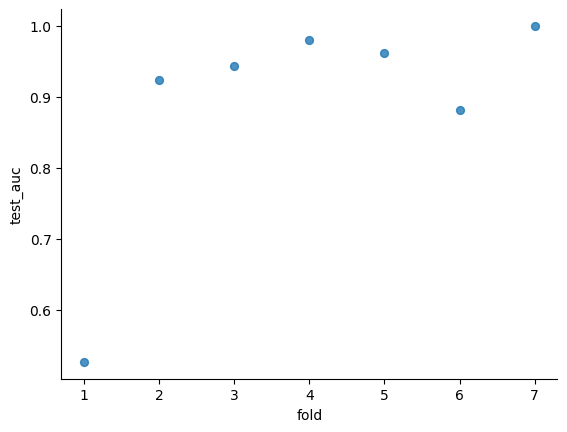

In [22]:
from matplotlib import pyplot as plt
metrics_df.plot(kind='scatter', x='fold', y='test_auc', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [23]:
import numpy as np
print(f"Mean TEST AUC: {np.nanmean(metrics_df['test_auc'].to_numpy(dtype=float)):.4f}")
print(f"Mean TEST ACC: {np.nanmean(metrics_df['test_acc_at_youden'].to_numpy(dtype=float)):.4f}")

Mean TEST AUC: 0.8879
Mean TEST ACC: 0.7301


Fold 01 | TEST AUC = 0.5261 | n=293


Fold 02 | TEST AUC = 0.9232 | n=124


Fold 03 | TEST AUC = 0.9439 | n=127
Fold 04 | TEST AUC = 0.9795 | n=69


Fold 05 | TEST AUC = 0.9617 | n=110
Fold 06 | TEST AUC = 0.8808 | n=243


Fold 07 | TEST AUC = 1.0000 | n=224


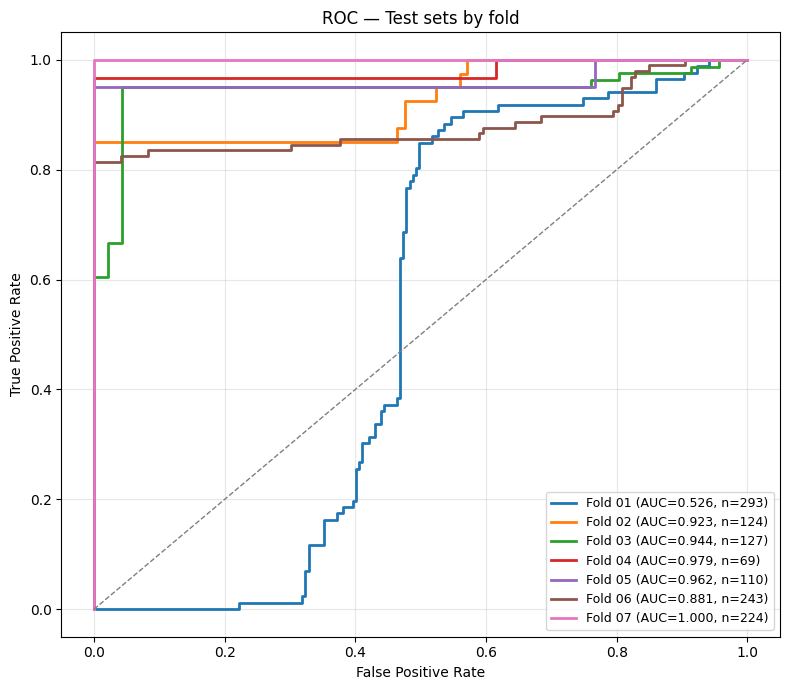

Saved combined ROC plot to: /content/drive/MyDrive/CD/2Bio_SHAP_v2/roc_curves_all_folds.png


In [24]:
# === Load per-fold weights & test sets, plot ROC with AUC for each fold ===
# Assumes these are already defined from your training script:
#   save_dir, K_FOLDS, BATCH_SIZE, ImageSequence, label_for_file
#   (and all data-loading helpers/ID_TO_FEAT used by ImageSequence)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow import keras

auc_rows = []
roc_data = []  # list of (fold_idx, fpr, tpr, auc, n)

for fold_idx in range(1, K_FOLDS + 1):
    fold_dir = Path(save_dir) / f"fold_{fold_idx:02d}"
    weights_file = fold_dir / f"best_fold_{fold_idx:02d}.h5"
    test_list = fold_dir / "test_files.txt"

    if not weights_file.exists() or not test_list.exists():
        print(f"(Fold {fold_idx:02d}) Missing weights or test_files.txt; skipping.")
        continue

    # Load test file paths
    test_files = [Path(line.strip()) for line in test_list.read_text().splitlines() if line.strip()]
    if len(test_files) == 0:
        print(f"(Fold {fold_idx:02d}) Empty test set; skipping.")
        continue

    # Eval generator (no shuffle, no noise)
    test_gen = ImageSequence(test_files, batch_size=BATCH_SIZE, shuffle=False, add_noise=False)

    # Load model and predict
    model = keras.models.load_model(str(weights_file))
    probs = model.predict(test_gen, verbose=0).ravel().astype(float)
    y_true = np.array([label_for_file(f) for f in test_gen.files], dtype=int)

    if len(np.unique(y_true)) < 2:
        print(f"(Fold {fold_idx:02d}) Only one class present; ROC/AUC undefined.")
        auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": np.nan})
        continue

    fpr, tpr, _ = roc_curve(y_true, probs)
    auc_val = roc_auc_score(y_true, probs)

    auc_rows.append({"fold": fold_idx, "n": len(y_true), "auc": float(auc_val)})
    roc_data.append((fold_idx, fpr, tpr, auc_val, len(y_true)))
    print(f"Fold {fold_idx:02d} | TEST AUC = {auc_val:.4f} | n={len(y_true)}")

# Save AUCs table
if auc_rows:
    auc_df = pd.DataFrame(auc_rows).sort_values("fold")
    auc_df.to_csv(Path(save_dir) / "auc_by_fold.csv", index=False)

# Plot all ROC curves in one figure with AUC in legend
if roc_data:
    plt.figure(figsize=(8, 7))
    for fold_idx, fpr, tpr, auc_val, n in roc_data:
        plt.plot(fpr, tpr, linewidth=2, label=f"Fold {fold_idx:02d} (AUC={auc_val:.3f}, n={n})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC — Test sets by fold")
    plt.legend(loc="lower right", fontsize=9, frameon=True)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out_png = Path(save_dir) / "roc_curves_all_folds.png"
    plt.savefig(out_png, dpi=200)
    plt.show()
    print(f"Saved combined ROC plot to: {out_png}")
else:
    print("No ROC data plotted (no valid folds).")

Mean TPR at fixed FPRs (unweighted, 7 folds):
  FPR=0.05 -> mean TPR=0.7917 (±0.3549)
  FPR=0.06 -> mean TPR=0.7917 (±0.3549)
  FPR=0.07 -> mean TPR=0.7917 (±0.3549)
  FPR=0.08 -> mean TPR=0.7917 (±0.3549)
  FPR=0.09 -> mean TPR=0.7932 (±0.3551)
  FPR=0.10 -> mean TPR=0.7932 (±0.3551)
  FPR=0.11 -> mean TPR=0.7932 (±0.3551)
  FPR=0.12 -> mean TPR=0.7932 (±0.3551)
  FPR=0.13 -> mean TPR=0.7932 (±0.3551)
  FPR=0.14 -> mean TPR=0.7932 (±0.3551)
  FPR=0.15 -> mean TPR=0.7932 (±0.3551)
  FPR=0.16 -> mean TPR=0.7932 (±0.3551)
  FPR=0.17 -> mean TPR=0.7932 (±0.3551)
  FPR=0.18 -> mean TPR=0.7932 (±0.3551)
  FPR=0.19 -> mean TPR=0.7932 (±0.3551)
  FPR=0.20 -> mean TPR=0.7932 (±0.3551)


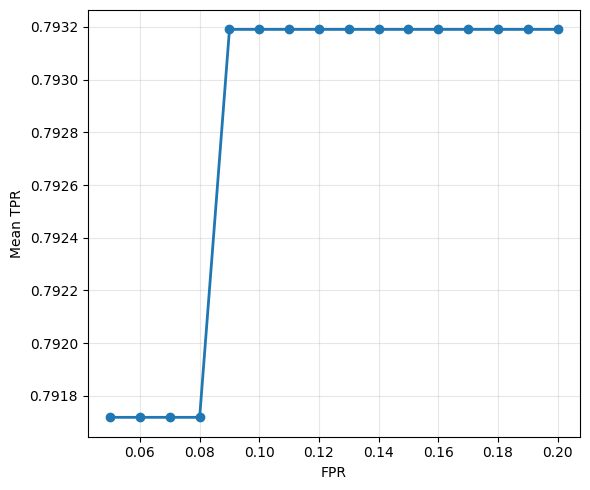

Saved mean TPR plot to: /content/drive/MyDrive/CD/2Bio_SHAP_v2/mean_tpr_at_fixed_fprs.png


In [25]:
# === Mean TPR at fixed FPRs across folds (right-continuous step function) ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# prerequisites: roc_data, save_dir
assert 'roc_data' in globals() and len(roc_data) > 0, "roc_data is empty; run ROC computation first."
assert 'save_dir' in globals(), "save_dir missing."

save_dir = Path(save_dir)
target_fprs = np.array([0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.20], dtype=float)

# If True, average folds weighted by their test-set size n; else plain mean.
WEIGHTED = False

per_fold_rows = []
per_fold_tpr = []
fold_sizes = []

for fold_idx, fpr, tpr, auc_val, n in roc_data:
    # 1) Collapse duplicate FPRs by keeping the MAX TPR at each FPR
    ufpr, inv = np.unique(fpr, return_inverse=True)
    tpr_max = np.zeros_like(ufpr, dtype=float)
    np.maximum.at(tpr_max, inv, tpr)

    # 2) Make it right-continuous / nondecreasing
    tpr_rc = np.maximum.accumulate(tpr_max)

    # 3) Evaluate stepwise TPR at or below the target FPRs (no linear interp)
    idxs = np.searchsorted(ufpr, target_fprs, side='right') - 1
    idxs = np.clip(idxs, 0, len(ufpr) - 1)
    tprs_at_targets = tpr_rc[idxs]

    per_fold_tpr.append(tprs_at_targets)
    fold_sizes.append(int(n))

    row = {"fold": int(fold_idx), "n": int(n)}
    row.update({f"tpr@{fp:.2f}": float(tv) for fp, tv in zip(target_fprs, tprs_at_targets)})
    per_fold_rows.append(row)

per_fold_tpr = np.vstack(per_fold_tpr)  # shape: (num_folds, 4)
fold_sizes = np.asarray(fold_sizes, dtype=float)

if WEIGHTED:
    w = fold_sizes / fold_sizes.sum()
    mean_tpr = (per_fold_tpr * w[:, None]).sum(axis=0)
    # weighted std (sqrt of weighted variance)
    var = (w[:, None] * (per_fold_tpr - mean_tpr) ** 2).sum(axis=0)
    std_tpr = np.sqrt(var)
else:
    mean_tpr = per_fold_tpr.mean(axis=0)
    std_tpr  = per_fold_tpr.std(axis=0, ddof=1) if per_fold_tpr.shape[0] > 1 else np.zeros_like(mean_tpr)

# Save CSVs
per_fold_df = pd.DataFrame(per_fold_rows).sort_values("fold")
per_fold_df.to_csv(save_dir / "tpr_at_fixed_fprs_by_fold.csv", index=False)

mean_df = pd.DataFrame({"fpr": target_fprs, "mean_tpr": mean_tpr, "std_tpr": std_tpr})
mean_df.to_csv(save_dir / "tpr_at_fixed_fprs_mean.csv", index=False)

# Console summary
avg_kind = "weighted" if WEIGHTED else "unweighted"
print(f"Mean TPR at fixed FPRs ({avg_kind}, {per_fold_tpr.shape[0]} folds):")
for fp, mt, st in zip(target_fprs, mean_tpr, std_tpr):
    print(f"  FPR={fp:.2f} -> mean TPR={mt:.4f} (±{st:.4f})")

# Plot mean TPR vs fixed FPRs
plt.figure(figsize=(6, 5))
plt.plot(target_fprs, mean_tpr, marker="o", linewidth=2)
plt.xlabel("FPR")
plt.ylabel("Mean TPR")
plt.grid(True, alpha=0.3)
plt.tight_layout()
out_png2 = save_dir / ("mean_tpr_at_fixed_fprs_weighted.png" if WEIGHTED else "mean_tpr_at_fixed_fprs.png")
plt.savefig(out_png2, dpi=200)
plt.show()
print(f"Saved mean TPR plot to: {out_png2}")


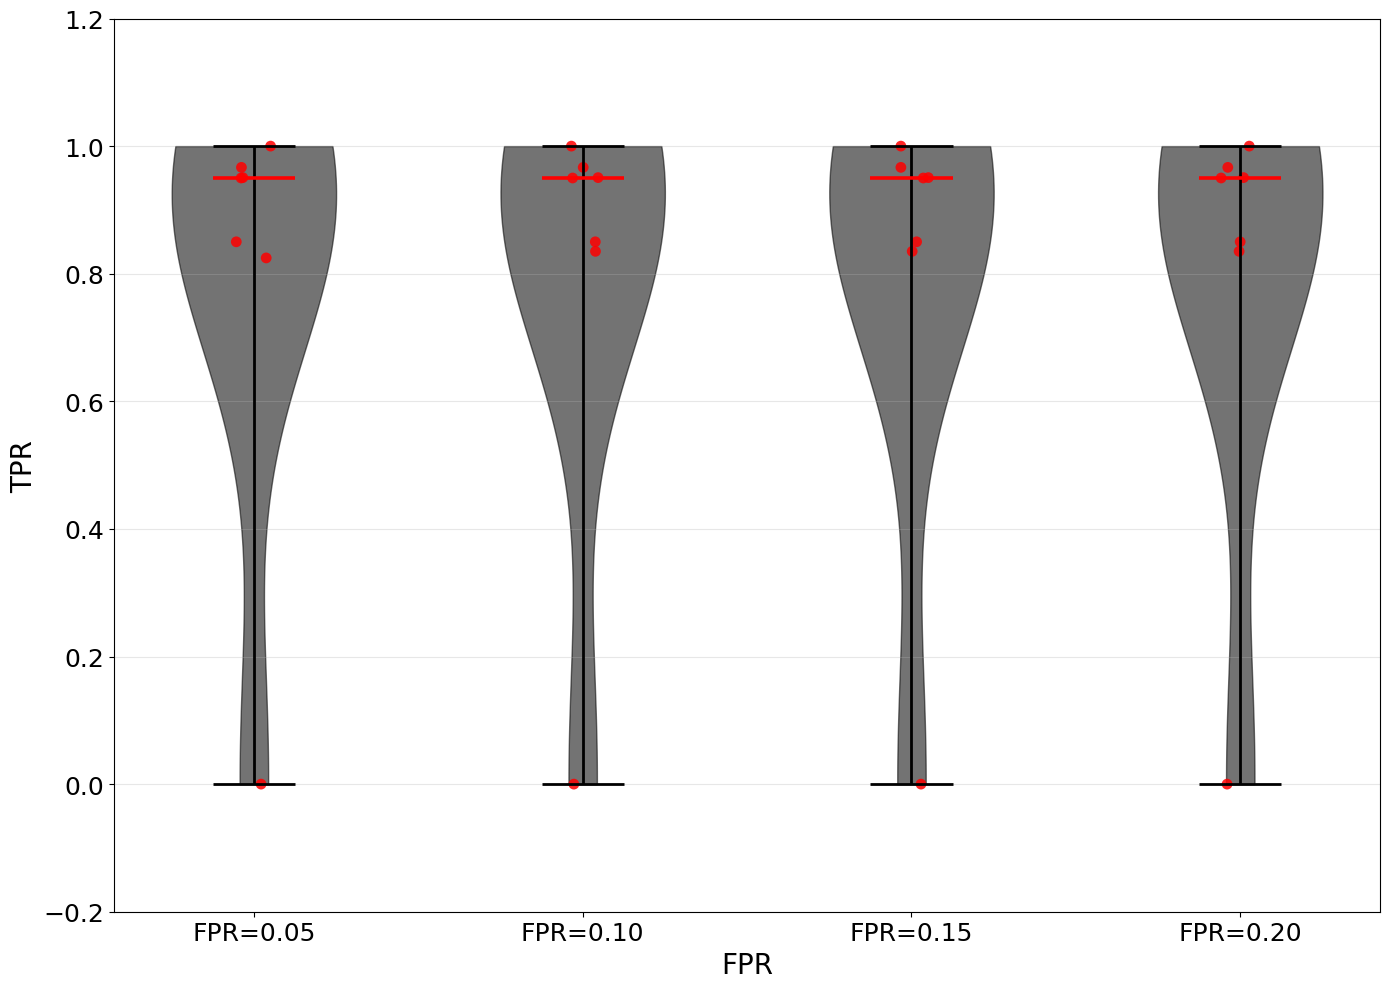

Saved violin plot to: /content/drive/MyDrive/CD/2Bio_SHAP_v2/tpr_violin_0p05_0p10_0p15_0p20_black_red.png


In [26]:
# === Violin plots of TPR across folds at selected FPRs (black violins, red medians & points) ===
selected_fprs = np.array([0.05, 0.10, 0.15, 0.20], dtype=float)

# map each selected FPR to the nearest index in target_fprs
sel_idx = [int(np.argmin(np.abs(target_fprs - fp))) for fp in selected_fprs]

# collect TPR vectors across folds at those indices
data_list = [per_fold_tpr[:, j] for j in sel_idx]

# optional: save the raw values table
viol_df = pd.DataFrame({f"tpr@{selected_fprs[i]:.2f}": data_list[i] for i in range(len(selected_fprs))})
viol_df.insert(0, "fold", [int(r["fold"]) for r in per_fold_rows])
viol_df.to_csv(save_dir / "tpr_violin_four_fprs_by_fold.csv", index=False)

# colors
COLOR_VIOLIN = "black"
COLOR_HILITE = "red"

# sizing
LABEL_FONTSIZE = 20
TICK_FONTSIZE  = 18
DOT_SIZE       = 60      # <- bigger dots
LINEWIDTH_MED  = 2.6
LINEWIDTH_EXT  = 2.0

fig, ax = plt.subplots(figsize=(14, 10))
parts = ax.violinplot(
    dataset=data_list,
    positions=np.arange(1, len(selected_fprs) + 1),
    showmeans=False, showmedians=True, showextrema=True
)

# black violins
for pc in parts['bodies']:
    pc.set_facecolor(COLOR_VIOLIN)
    pc.set_edgecolor(COLOR_VIOLIN)
    pc.set_alpha(0.55)

# black whiskers/bars; red medians
if 'cmins' in parts:    parts['cmins'].set_color(COLOR_VIOLIN);  parts['cmins'].set_linewidth(LINEWIDTH_EXT)
if 'cmaxes' in parts:   parts['cmaxes'].set_color(COLOR_VIOLIN); parts['cmaxes'].set_linewidth(LINEWIDTH_EXT)
if 'cbars' in parts:    parts['cbars'].set_color(COLOR_VIOLIN);  parts['cbars'].set_linewidth(LINEWIDTH_EXT)
if 'cmedians' in parts: parts['cmedians'].set_color(COLOR_HILITE); parts['cmedians'].set_linewidth(LINEWIDTH_MED)

# overlay per-fold points (red) with slight jitter
rng = np.random.default_rng(123)
for i, vals in enumerate(data_list, start=1):
    jitter = rng.uniform(-0.06, 0.06, size=vals.shape[0])
    ax.scatter(np.full_like(vals, i, dtype=float) + jitter, vals,
               s=DOT_SIZE, alpha=0.85, color=COLOR_HILITE, edgecolors='none')

ax.set_xticks(np.arange(1, len(selected_fprs) + 1))
ax.set_xticklabels([f"FPR={fp:.2f}" for fp in selected_fprs], fontsize=TICK_FONTSIZE)
ax.set_ylim(-0.2, 1.2)
ax.set_xlabel("FPR", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("TPR", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
ax.grid(axis="y", alpha=0.3)

out_violin = save_dir / "tpr_violin_0p05_0p10_0p15_0p20_black_red.png"
fig.tight_layout()
fig.savefig(out_violin, dpi=200)
plt.show()
print(f"Saved violin plot to: {out_violin}")


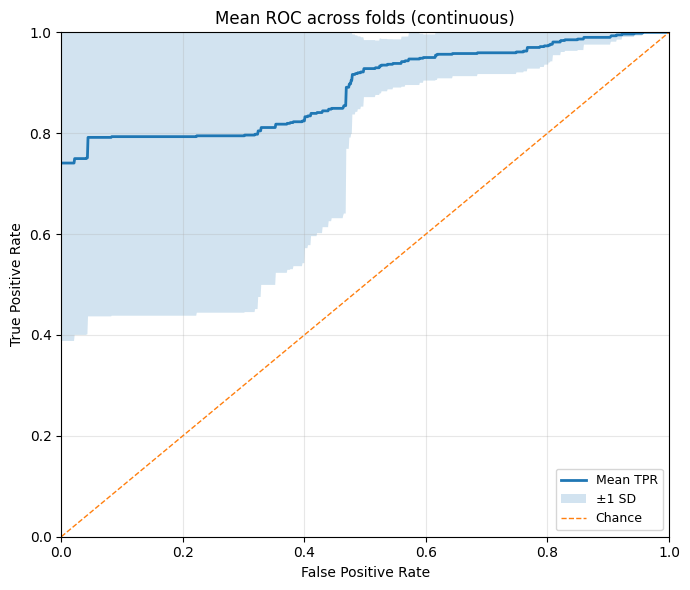

Saved: /content/drive/MyDrive/CD/2Bio_SHAP_v2/mean_tpr_curve_full.png


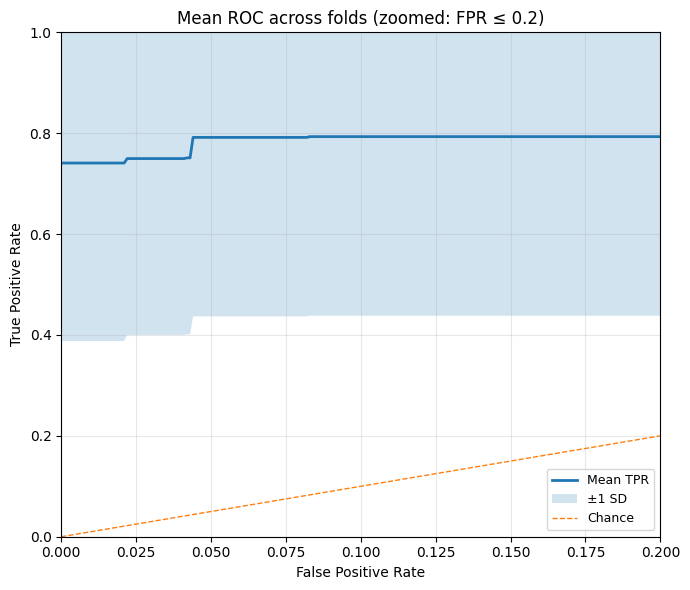

Saved: /content/drive/MyDrive/CD/2Bio_SHAP_v2/mean_tpr_curve_zoom_0_0.2.png


In [27]:
# === Continuous mean ROC across folds (right-continuous step averaging) ===
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert 'roc_data' in globals() and len(roc_data) > 0, "roc_data is empty; run ROC computation first."
assert 'save_dir' in globals(), "save_dir missing."

save_dir = Path(save_dir)

# Config
WEIGHTED = False          # set True to weight folds by their test-set size (n)
N_GRID   = 1001           # resolution of the FPR grid
fpr_grid = np.linspace(0.0, 1.0, N_GRID)

per_fold_grid = []
fold_sizes = []

for fold_idx, fpr, tpr, auc_val, n in roc_data:
    # Collapse duplicate FPRs by keeping the MAX TPR, then make nondecreasing (right-continuous)
    ufpr, inv = np.unique(fpr, return_inverse=True)
    tpr_max = np.zeros_like(ufpr, dtype=float)
    np.maximum.at(tpr_max, inv, tpr)
    tpr_rc = np.maximum.accumulate(tpr_max)

    # Stepwise evaluation at/below each grid FPR (no linear interpolation)
    idxs = np.searchsorted(ufpr, fpr_grid, side='right') - 1
    idxs = np.clip(idxs, 0, len(ufpr) - 1)
    tpr_on_grid = tpr_rc[idxs]

    per_fold_grid.append(tpr_on_grid)
    fold_sizes.append(int(n))

per_fold_grid = np.vstack(per_fold_grid)  # shape: (num_folds, N_GRID)
fold_sizes = np.asarray(fold_sizes, dtype=float)

# Mean / SD across folds
if WEIGHTED:
    w = fold_sizes / fold_sizes.sum()
    mean_tpr = (per_fold_grid * w[:, None]).sum(axis=0)
    var = (w[:, None] * (per_fold_grid - mean_tpr) ** 2).sum(axis=0)
    std_tpr = np.sqrt(var)
else:
    mean_tpr = per_fold_grid.mean(axis=0)
    std_tpr  = per_fold_grid.std(axis=0, ddof=1) if per_fold_grid.shape[0] > 1 else np.zeros_like(mean_tpr)

# Save the continuous mean curve
mean_curve_df = pd.DataFrame({"fpr": fpr_grid, "mean_tpr": mean_tpr, "std_tpr": std_tpr})
mean_curve_df.to_csv(save_dir / ("mean_tpr_curve_weighted.csv" if WEIGHTED else "mean_tpr_curve.csv"), index=False)

# ---- Plot 1: full 0–1 ----
plt.figure(figsize=(7, 6))
plt.plot(fpr_grid, mean_tpr, linewidth=2, label="Mean TPR")
plt.fill_between(fpr_grid, np.maximum(0, mean_tpr - std_tpr), np.minimum(1, mean_tpr + std_tpr),
                 alpha=0.2, label="±1 SD")
plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Chance")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC across folds (continuous)")
plt.legend(loc="lower right", fontsize=9, frameon=True)
plt.grid(True, alpha=0.3)
out_full = save_dir / ("mean_tpr_curve_full_weighted.png" if WEIGHTED else "mean_tpr_curve_full.png")
plt.tight_layout(); plt.savefig(out_full, dpi=200); plt.show()
print(f"Saved: {out_full}")

# ---- Plot 2: zoomed 0–0.2 ----
mask = fpr_grid <= 0.20
plt.figure(figsize=(7, 6))
plt.plot(fpr_grid[mask], mean_tpr[mask], linewidth=2, label="Mean TPR")
plt.fill_between(fpr_grid[mask],
                 np.maximum(0, (mean_tpr - std_tpr)[mask]),
                 np.minimum(1, (mean_tpr + std_tpr)[mask]),
                 alpha=0.2, label="±1 SD")
plt.plot([0, 0.2], [0, 0.2], "--", linewidth=1, label="Chance")
plt.xlim(0, 0.2); plt.ylim(0, 1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Mean ROC across folds (zoomed: FPR ≤ 0.2)")
plt.legend(loc="lower right", fontsize=9, frameon=True)
plt.grid(True, alpha=0.3)
out_zoom = save_dir / ("mean_tpr_curve_zoom_0_0.2_weighted.png" if WEIGHTED else "mean_tpr_curve_zoom_0_0.2.png")
plt.tight_layout(); plt.savefig(out_zoom, dpi=200); plt.show()
print(f"Saved: {out_zoom}")
